In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plot

dtFrame = pd.read_csv("./dataset_tugas1_preprocessing.csv")
dtFrame


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0
...,...,...,...,...,...,...,...,...
94,MH095,Gita,Laki-laki,Teknik Komputer,Aktif,D,2022/02/25,21.0
95,MH096,Adi,Laki-laki,Sistem Informasi,Lulus,C,2021/04/14,20.0
96,MH097,Iwan,Laki-laki,Data Science,Lulus,D,2020/01/11,NaN
97,MH098,Eka,Perempuan,Data Science,Aktif,A,2022/01/29,22.0


In [2]:
print(dtFrame.isnull().sum(axis=0))
dtFrameNull = dtFrame[dtFrame.isnull().any(axis=1)]
dtFrameNull

ID                0
Nama              0
Jenis_Kelamin     0
Prodi             0
Status            0
Nilai_Akhir      29
Tanggal_Ujian     0
Umur              9
dtype: int64


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
7,MH008,Joko,Perempuan,Data Science,Cuti,NaN,2020/09/16,19.0
12,MH013,Budi,Perempuan,Teknik Komputer,Aktif,D,2021/02/19,NaN
14,MH015,Citra,Laki-laki,Sistem Informasi,Cuti,NaN,2022/04/22,25.0
21,MH022,Dina,Perempuan,Teknik Komputer,DO,NaN,2020/05/26,18.0
24,MH025,Gita,Perempuan,Informatika,Lulus,D,2022/07/08,NaN
26,MH027,Hana,Perempuan,Informatika,DO,NaN,2020/05/10,26.0
27,MH028,Gita,Laki-laki,Informatika,DO,NaN,2020/03/16,19.0
28,MH029,Iwan,Perempuan,Data Science,Cuti,NaN,2020/05/05,20.0


In [3]:
UmurMean = dtFrame.Umur.mean()
dtFrame.fillna({"Nilai_Akhir":"Kosong","Umur": UmurMean},inplace=True)
print(dtFrame.isnull().sum(axis=0))
dtFrame

ID               0
Nama             0
Jenis_Kelamin    0
Prodi            0
Status           0
Nilai_Akhir      0
Tanggal_Ujian    0
Umur             0
dtype: int64


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,Kosong,13-04-2020,23.366667
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.000000
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,Kosong,2021/11/21,23.000000
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.000000
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.000000
...,...,...,...,...,...,...,...,...
94,MH095,Gita,Laki-laki,Teknik Komputer,Aktif,D,2022/02/25,21.000000
95,MH096,Adi,Laki-laki,Sistem Informasi,Lulus,C,2021/04/14,20.000000
96,MH097,Iwan,Laki-laki,Data Science,Lulus,D,2020/01/11,23.366667
97,MH098,Eka,Perempuan,Data Science,Aktif,A,2022/01/29,22.000000


In [4]:
dateFormat = pd.DataFrame(columns=['Tanggal_Ujian'])
dateFormat.Tanggal_Ujian =  pd.to_datetime(dtFrame.Tanggal_Ujian,errors='coerce',format="mixed")
dtFrame.Tanggal_Ujian = dateFormat.Tanggal_Ujian.dt.strftime("%d-%m-%Y")

print (dtFrame[dtFrame["Tanggal_Ujian"].isna()])
dtFrame

Empty DataFrame
Columns: [ID, Nama, Jenis_Kelamin, Prodi, Status, Nilai_Akhir, Tanggal_Ujian, Umur]
Index: []


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,Kosong,13-04-2020,23.366667
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,11-12-2020,28.000000
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,Kosong,21-11-2021,23.000000
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,19-08-2021,18.000000
4,MH005,Joko,Perempuan,Data Science,Aktif,C,05-01-2020,26.000000
...,...,...,...,...,...,...,...,...
94,MH095,Gita,Laki-laki,Teknik Komputer,Aktif,D,25-02-2022,21.000000
95,MH096,Adi,Laki-laki,Sistem Informasi,Lulus,C,14-04-2021,20.000000
96,MH097,Iwan,Laki-laki,Data Science,Lulus,D,11-01-2020,23.366667
97,MH098,Eka,Perempuan,Data Science,Aktif,A,29-01-2022,22.000000


In [5]:
   
dataCollumn = {"Nama","Jenis_Kelamin","Prodi","Status","Nilai_Akhir"}
dataNumerk = {"Tanggal_Ujian","Umur"}
dtEncodded = pd.DataFrame()
Encoder = {}
for col in dataCollumn:
    Encoder[col] = {label:idx for idx,label in enumerate(np.unique(dtFrame[col]))}
    dtEncodded[col] = dtFrame[col].map(Encoder[col])
for col in dataNumerk:
    dtEncodded[col] = dtFrame[col]

for key,val in Encoder.items():
    print(f"{key}, {val}") 
dtEncodded

Nilai_Akhir, {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'Kosong': 5}
Status, {'Aktif': 0, 'Cuti': 1, 'DO': 2, 'Lulus': 3}
Nama, {'Adi': 0, 'Budi': 1, 'Citra': 2, 'Dina': 3, 'Eka': 4, 'Farhan': 5, 'Gita': 6, 'Hana': 7, 'Iwan': 8, 'Joko': 9}
Jenis_Kelamin, {'Laki-laki': 0, 'Perempuan': 1}
Prodi, {'Data Science': 0, 'Informatika': 1, 'Sistem Informasi': 2, 'Teknik Komputer': 3}


,Nilai_Akhir,Status,Nama,Jenis_Kelamin,Prodi,Tanggal_Ujian,Umur
0,5,0,8,0,3,13-04-2020,23.366667
1,4,3,4,1,3,11-12-2020,28.000000
2,5,0,8,0,3,21-11-2021,23.000000
3,3,0,4,1,3,19-08-2021,18.000000
4,2,0,9,1,0,05-01-2020,26.000000
...,...,...,...,...,...,...,...
94,3,0,6,0,3,25-02-2022,21.000000
95,2,3,0,0,2,14-04-2021,20.000000
96,3,3,8,0,0,11-01-2020,23.366667
97,0,0,4,1,0,29-01-2022,22.000000


In [6]:
X_train,X_test = {},{}
y_Train,y_test = {},{}
for key in dtEncodded.columns:
    if key == "Tanggal_Ujian": continue
    X = dtEncodded.drop(key,axis=1)
    y = dtEncodded[key]
    xtr,xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
    X_train[key],X_test[key] = xtr,xte
    y_Train[key],y_test[key] = ytr,yte
    print(f"jumlah daya latih {key} :{X_train[key].shape[0]} \njumlah daya uji {key} : {X_test[key].shape[0]}\n")




jumlah daya latih Nilai_Akhir :79 
jumlah daya uji Nilai_Akhir : 20

jumlah daya latih Status :79 
jumlah daya uji Status : 20

jumlah daya latih Nama :79 
jumlah daya uji Nama : 20

jumlah daya latih Jenis_Kelamin :79 
jumlah daya uji Jenis_Kelamin : 20

jumlah daya latih Prodi :79 
jumlah daya uji Prodi : 20

jumlah daya latih Umur :79 
jumlah daya uji Umur : 20



[Text(0, 0, 'Data Science'),
 Text(1, 0, 'Informatika'),
 Text(2, 0, 'Sistem Informasi'),
 Text(3, 0, 'Teknik Komputer')]

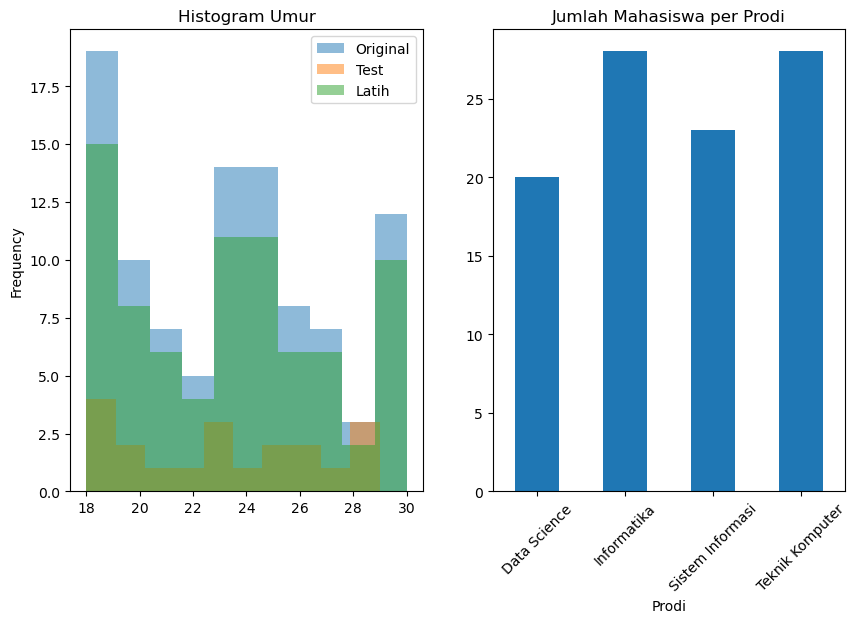

In [ ]:
fig,axes = plot.subplots(nrows=1,ncols=2,gridspec_kw={'width_ratios':[3,3]})
fig.set_size_inches(10,6)
dtEncodded["Umur"].plot.hist(ax=axes[0],alpha=0.5,label="Original",legend=True)
y_test["Umur"].plot.hist(ax=axes[0],alpha=0.5,label="Test",legend=True)
y_Train["Umur"].plot.hist(ax=axes[0],alpha=0.5,label="Latih",legend=True)
dtEncodded["Prodi"].value_counts().sort_index().plot(kind="bar",ax=axes[1])
NamaProdi = Encoder["Prodi"]
axes[0].set_title("Histogram Umur")
axes[1].set_title("Jumlah Mahasiswa per Prodi")
axes[1].set_xticklabels(NamaProdi,rotation=45)